<a href="https://colab.research.google.com/github/Isuru401/Statistical-Learning-e22401/blob/main/assignemente22401.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mathematical Proofs for the Linear Filter Model (Kalman Filter)

We are dealing with a linear Gaussian state-space model. The core mathematical tool we will use throughout these proofs is the linear transformation property of Gaussian vectors:
If $X \sim \mathscr{N}(\mu, \Sigma)$, then for any deterministic matrix $M$ and vector $b$, the transformed variable $MX + b \sim \mathscr{N}(M\mu + b, M\Sigma M^T)$.

---

### 1. Proof for the State Prediction ($x_k^-$)

We are given the state transition equation:
$$x^{-}_k = A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}$$
where $x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$, and we assume the process noise is zero-mean with covariance $\Sigma_p$, i.e., $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$, acting independently of $x^{+}_{k-1}$.

**Step 1: Finding the Mean ($m_k^-$)**
By taking the mathematical expectation on both sides:
$$m_k^- = \mathbb{E}[x^{-}_k] = \mathbb{E}[A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}]$$
Because expectation is a linear operator:
$$m_k^- = A_{k-1}\mathbb{E}[x^{+}_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}]$$
Since $\mathbb{E}[x^{+}_{k-1}] = m_{k-1}$ and $\mathbb{E}[w_{k-1}] = 0$:
$$m_k^- = A_{k-1}m_{k-1}$$

**Step 2: Finding the Covariance ($P_k^-$)**
By definition of covariance for the sum of two independent random vectors:
$$P_k^- = \text{Var}(x^{-}_k) = \text{Var}(A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1})$$
Using the property $\text{Var}(MX) = M\text{Var}(X)M^T$:
$$P_k^- = A_{k-1}\text{Var}(x^{+}_{k-1})A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T$$
Substituting $\text{Var}(x^{+}_{k-1}) = P_{k-1}$ and $\text{Var}(w_{k-1}) = \Sigma_p$:
$$P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$

Since a linear combination of independent Gaussian variables remains Gaussian, we conclude:
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$$

---

### 2. Proof for the Measurement Prediction ($y_k^-$)

The measurement equation is given by:
$$y^{-}_k = H_k\,x^{-}_k + z_k$$
where $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$ (from Step 1) and the measurement noise $z_k \sim \mathscr{N}(0, \Sigma_m)$ is independent of $x_k^-$.

**Step 1: Finding the Mean**
$$\mathbb{E}[y^{-}_k] = \mathbb{E}[H_k\,x^{-}_k + z_k] = H_k\mathbb{E}[x^{-}_k] + \mathbb{E}[z_k]$$
Since $\mathbb{E}[x^{-}_k] = m_k^-$ and $\mathbb{E}[z_k] = 0$:
$$\mathbb{E}[y^{-}_k] = H_k m_k^-$$

**Step 2: Finding the Covariance**
Using the independence of $x_k^-$ and $z_k$:
$$\text{Var}(y^{-}_k) = \text{Var}(H_k\,x^{-}_k) + \text{Var}(z_k)$$
$$\text{Var}(y^{-}_k) = H_k\text{Var}(x^{-}_k)H_k^T + \Sigma_m$$
$$\text{Var}(y^{-}_k) = H_k P_k^- H_k^T + \Sigma_m$$

Thus, the measurement vector distribution is:
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$$

---

### 3. Proof for the Joint Distribution

We look to frame $x_k^-$ and $y_k^-$ into a single joint Gaussian vector:
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left( \mu_{\text{joint}}, \Sigma_{\text{joint}} \right)$$

**Step 1: Joint Mean Matrix**
The stacked expectations are trivial to extract from our previous answers:
$$\mu_{\text{joint}} = \begin{bmatrix} \mathbb{E}[x_k^-] \\ \mathbb{E}[y^{-}_k] \end{bmatrix} = \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}$$

**Step 2: Joint Covariance Matrix**
The block covariance matrix takes the structure:
$$\Sigma_{\text{joint}} = \begin{bmatrix} \text{Var}(x_k^-) & \text{Cov}(x_k^-, y_k^-) \\ \text{Cov}(y_k^-, x_k^-) & \text{Var}(y_k^-) \end{bmatrix}$$

We already know $\text{Var}(x_k^-) = P_k^-$ and $\text{Var}(y_k^-) = H_k P_k^- H_k^T + \Sigma_m$. Let's calculate the cross-covariance terms:
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[ (x_k^- - m_k^-)(y_k^- - H_k m_k^-)^T \right]$$
Substitute $y_k^- = H_k x_k^- + z_k$:
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[ (x_k^- - m_k^-)(H_k x_k^- + z_k - H_k m_k^-)^T \right]$$
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[ (x_k^- - m_k^-)(x_k^- - m_k^-)^T H_k^T + (x_k^- - m_k^-)z_k^T \right]$$

Because $x_k^-$ and $z_k$ are independent, $\mathbb{E}[(x_k^- - m_k^-)z_k^T] = 0$. Therefore:
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}\left[ (x_k^- - m_k^-)(x_k^- - m_k^-)^T \right] H_k^T = P_k^- H_k^T$$
Naturally, its transpose yields the other off-diagonal element: $\text{Cov}(y_k^-, x_k^-) = H_k P_k^-$.

Putting it all together into block format:
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix} \right)$$

---

### 4 & 5. Proof for Conditional Distribution (Measurement Update)

When we get an actual observation $y_k^- = y^{\mathrm{obs}}_{k}$, we condition the joint distribution using the standard **Gaussian Conditioning Rule**.
For a joint Gaussian system structured as $\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left( \begin{bmatrix} \mu_x \\ \mu_y \end{bmatrix}, \begin{bmatrix} \Sigma_{xx} & \Sigma_{xy} \\ \Sigma_{yx} & \Sigma_{yy} \end{bmatrix} \right)$, the conditional distribution $(X \mid Y = y)$ is Gaussian with:
$$\mathbb{E}[X \mid Y=y] = \mu_x + \Sigma_{xy} \Sigma_{yy}^{-1} (y - \mu_y)$$
$$\text{Var}(X \mid Y=y) = \Sigma_{xx} - \Sigma_{xy} \Sigma_{yy}^{-1} \Sigma_{yx}$$

Mapping our joint variables from **Question 3** directly into this rule:
* $\mu_x = m_k^-$
* $\mu_y = H_k m_k^-$
* $\Sigma_{xx} = P_k^-$
* $\Sigma_{xy} = P_k^- H_k^T$
* $\Sigma_{yx} = H_k P_k^-$
* $\Sigma_{yy} = H_k P_k^- H_k^T + \Sigma_m$

**Step 1: Defining the Kalman Gain ($K_k$)**
Let $K_k = \Sigma_{xy} \Sigma_{yy}^{-1}$. Substituting our specific matrix blocks gives:
$$K_k \triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$

**Step 2: Calculating the Conditional Mean ($\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$)**
Applying the conditioning expectation rule:
$$m_k = \mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$

**Step 3: Calculating the Conditional Covariance ($\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$)**
Applying the conditioning variance rule:
$$P_k = \text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = P_k^- - K_k (H_k P_k^-)$$
Factoring out $P_k^-$ from the right-hand side yields:
$$P_k = (I - K_k H_k) P_k^-$$

Hence, both **Question 4** and **Question 5** are fundamentally solved via the exact same identity, demonstrating that:
$$x^{+}_k \sim \mathscr{N}(m_k, P_k)$$

# Q. 1-D Example

\documentclass[11pt]{article}
\usepackage{amsmath, amssymb, amsfonts, mathrsfs, graphicx, hyperref, listings, color}

\definecolor{dkgreen}{rgb}{0,0.6,0}
\definecolor{gray}{rgb}{0.5,0.5,0.5}
\definecolor{mauve}{rgb}{0.58,0,0.82}

\lstset{frame=tb,
  language=Python,
  aboveskip=3mm,
  belowskip=3mm,
  showstringspaces=false,
  columns=flexible,
  basicstyle={\small\ttfamily},
  numbers=none,
  numberstyle=\tiny\color{gray},
  keywordstyle=\color{blue},
  commentstyle=\color{dkgreen},
  stringstyle=\color{mauve},
  breaklines=true,
  breakatwhitespace=true,
  tabsize=3
}

\begin{document}

\title{Derivation and Simulation of the Scalar Linear-Gaussian Filter}
\author{Kalman Filtering Analysis}
\date{\today}
\maketitle

\section{Problem Framework}
Consider the scalar linear-Gaussian filter model:
\begin{align}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q) \\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r)
\end{align}
with prior state $x_0\sim \mathscr{N}(m_0,P_0)$. We define the history of observations up to step $k$ as $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

---

\section{Mathematical Step-by-Step Derivations}

\subsection{Part 1: Time Update (State Prediction)}
We want to derive the mean $m_k^-$ and variance $P_k^-$ of the predictive state distribution $p(x_k \mid Y_{k-1}) = \mathscr{N}(m_k^-, P_k^-)$, given the previous step's posterior distribution $p(x_{k-1} \mid Y_{k-1}) = \mathscr{N}(m_{k-1}, P_{k-1})$.

\subsubsection{1. Predicted Mean ($m_k^-$)}
Taking the conditional expectation of the state transition equation with respect to the history $Y_{k-1}$:
\begin{align*}
m_k^- = \mathbb{E}[x^-_k \mid Y_{k-1}] &= \mathbb{E}[a\,x^+_{k-1} + w_{k-1} \mid Y_{k-1}] \\
&= a\,\mathbb{E}[x^+_{k-1} \mid Y_{k-1}] + \mathbb{E}[w_{k-1}]
\end{align*}
Because the process noise $w_{k-1}$ has zero mean and is independent of the past, we obtain:
\begin{equation}
m_k^- = a\,m_{k-1}
\end{equation}

\subsubsection{2. Predicted Covariance ($P_k^-$)}
Using the variance operator properties for conditional independent variables:
\begin{align*}
P_k^- = \text{Var}(x^-_k \mid Y_{k-1}) &= \text{Var}(a\,x^+_{k-1} + w_{k-1} \mid Y_{k-1}) \\
&= a^2 \text{Var}(x^+_{k-1} \mid Y_{k-1}) + \text{Var}(w_{k-1})
\end{align*}
Substituting our known variance parameters yield:
\begin{equation}
P_k^- = a^2 P_{k-1} + q
\end{equation}

---

\subsection{Part 2: Measurement Update (State Correction)}
The measurement model is $y_k = h\,x_k + z_k$, where $z_k \sim \mathscr{N}(0,r)$. The joint distribution of the state $x_k$ and the measurement $y_k$ conditioned on past history $Y_{k-1}$ forms a joint Gaussian:
\begin{equation*}
\begin{bmatrix} x_k \\ y_k \end{bmatrix} \bigg| Y_{k-1} \sim \mathscr{N} \left( \begin{bmatrix} m_k^- \\ h m_k^- \end{bmatrix}, \begin{bmatrix} P_k^- & P_k^- h \\ h P_k^- & S_k \end{bmatrix} \right)
\end{equation*}
where $S_k = h^2 P_k^- + r$ represents the innovation covariance.

By applying the standard property of conditional Gaussian distributions, if $\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left(\begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix}\right)$, then:
\begin{align*}
\mu_{X|Y} &= \mu_X + \Sigma_{XY} \Sigma_{YY}^{-1} (y - \mu_Y) \\
\Sigma_{X|Y} &= \Sigma_{XX} - \Sigma_{XY} \Sigma_{YY}^{-1} \Sigma_{YX}
\end{align*}

\subsubsection{1. Posterior Mean ($m_k$)}
Substituting our elements directly into the joint conditioning identity properties:
\begin{align*}
m_k &= m_k^- + P_k^- h (S_k)^{-1} (y^{\mathrm{obs}}_k - h m_k^-) \\
&= m_k^- + K_k\,v_k
\end{align*}
where $K_k = \frac{P_k^- h}{S_k}$ is the Kalman Gain and $v_k = \bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr)$ is the innovation error.

\subsubsection{2. Posterior Covariance ($P_k$)}
Evaluating the conditional update equation for covariance yields:
\begin{align*}
P_k &= P_k^- - (P_k^- h)(S_k)^{-1}(h P_k^-) \\
&= P_k^- - K_k h P_k^- \\
&= (1 - K_k h) P_k^-
\end{align*}
Replacing $K_k$ explicitly with its definition gives:
\begin{equation}
P_k = \left(1 - \frac{P_k^- h^2}{S_k}\right) P_k^-
\end{equation}

---

\subsection{Part 3: Predictive Measurement Distribution}
Before evaluating the incoming observation $y_k^{\mathrm{obs}}$, the measurement behaves as a random variable $y^-_k = h\,x^-_k + z_k$.

\subsubsection{1. Mean}
\begin{align*}
\mathbb{E}[y^-_k \mid Y_{k-1}] &= \mathbb{E}[h\,x^-_k + z_k \mid Y_{k-1}] \\
&= h\,\mathbb{E}[x^-_k \mid Y_{k-1}] + \mathbb{E}[z_k] \\
&= h\,m_k^-
\end{align*}

\subsubsection{2. Variance}
Since $x^-_k$ and the current measurement noise $z_k$ are statistically independent, variances add cleanly:
\begin{align*}
\text{Var}(y^-_k \mid Y_{k-1}) &= \text{Var}(h\,x^-_k + z_k \mid Y_{k-1}) \\
&= h^2 \text{Var}(x^-_k \mid Y_{k-1}) + \text{Var}(z_k) \\
&= h^2 P_k^- + r
\end{align*}
Thus, the predictive distribution yields:
\begin{equation}
p(y^-_k \mid Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr)
\end{equation}

---

\subsection{Part 4: Posterior-Predictive Measurement Distribution}
After filtering on $y_k$, we observe the measurement space projection through the updated posterior state distribution $p(x_k \mid Y_k) = \mathscr{N}(m_k, P_k)$.

\subsubsection{1. Mean}
\begin{align*}
\mathbb{E}[y^-_k \mid Y_k] &= \mathbb{E}[h\,x_k + z_k \mid Y_k] = h\,m_k
\end{align*}

\subsubsection{2. Variance}
\begin{align*}
\text{Var}(y^-_k \mid Y_k) &= \text{Var}(h\,x_k + z_k \mid Y_k) = h^2 P_k + r
\end{align*}
Thus, the posterior-predictive distribution yields:
\begin{equation}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr)
\end{equation}

---

\section{Part 5: Numerical Simulation and Animation Code}
Below is the clean Python script designed to execute inside a Google Colab environment to simulate and render the prior vs. posterior tracking distributions dynamically.

\begin{lstlisting}[language=Python]
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import HTML

# 1. Define suitable numerical parameters
np.random.seed(42)
num_steps = 30
a = 0.95    # State transition parameter
q = 0.4     # Process noise variance
h = 1.2     # Measurement parameter
r = 0.5     # Measurement noise variance

# True initial state and filter initialization
x_true = 0.0
m_0 = 2.0   # Deliberately offset prior mean to watch it converge
P_0 = 1.5

# Data arrays for plot generation
true_states = []
measurements = []
priors = []     
posteriors = []

m, P = m_0, P_0

# 2. Generate System Data and Run Kalman Filter
for k in range(num_steps):
    # Process evolution
    w = np.random.normal(0, np.sqrt(q))
    x_true = a * x_true + w
    true_states.append(x_true)
    
    # Measurement generation
    z = np.random.normal(0, np.sqrt(r))
    y_obs = h * x_true + z
    measurements.append(y_obs)
    
    # KF Time Update (Prior State)
    m_minus = a * m
    P_minus = (a**2) * P + q
    priors.append((m_minus, P_minus))
    
    # KF Measurement Update (Posterior State)
    S = (h**2) * P_minus + r
    K = (P_minus * h) / S
    m = m_minus + K * (y_obs - h * m_minus)
    P = (1 - K * h) * P_minus
    posteriors.append((m, P))

# 3. Setup Animation Canvas Layout
fig, ax = plt.subplots(figsize=(10, 6))
x_axis = np.linspace(-6, 6, 500)

line_prior, = ax.plot([], [], 'r-', lw=2, label='Prior State $p(x_k|Y_{k-1})$')
line_post, = ax.plot([], [], 'b-', lw=2, label='Posterior State $p(x_k|Y_k)$')
vline_true = ax.axvline(0, color='g', linestyle='--', lw=2, label='True State $x_k$')

ax.set_xlim(-6, 6)
ax.set_ylim(0, 1.5)
ax.set_title('Kalman Filter State Evolution Animation', fontsize=14)
ax.set_xlabel('State space ($x$)', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

def init():
    line_prior.set_data([], [])
    line_post.set_data([], [])
    return line_prior, line_post, vline_true

def update(frame):
    m_m, P_m = priors[frame]
    m_p, P_p = posteriors[frame]
    xt = true_states[frame]
    
    # Compute Gaussian density profiles
    y_prior = norm.pdf(x_axis, m_m, np.sqrt(P_m))
    y_post = norm.pdf(x_axis, m_p, np.sqrt(P_p))
    
    line_prior.set_data(x_axis, y_prior)
    line_post.set_data(x_axis, y_post)
    vline_true.set_xdata([xt, xt])
    
    ax.set_title(f'Kalman Filter State Evolution - Step {frame+1}/{num_steps}', fontsize=14)
    return line_prior, line_post, vline_true

# Render HTML5 video output format for Google Colab compatibility
anim = FuncAnimation(fig, update, frames=num_steps, init_func=init, blit=True, interval=500)
plt.close()
HTML(anim.to_jshtml())
\end{lstlisting}

\end{document}

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import HTML

# 1. Define suitable numerical parameters
np.random.seed(42)
num_steps = 30
a = 0.95    # State transition parameter
q = 0.4     # Process noise variance
h = 1.2     # Measurement parameter
r = 0.5     # Measurement noise variance

# True initial state and filter initialization
x_true = 0.0
m_0 = 2.0   # Deliberately offset prior mean to watch it converge
P_0 = 1.5

# Arrays to store tracking data
true_states = []
measurements = []
priors = []     # Store pairs of (m_minus, P_minus)
posteriors = [] # Store pairs of (m, P)

m = m_0
P = P_0

# 2. Generate Data and Run Kalman Filter
for k in range(num_steps):
    # Process evolution
    w = np.random.normal(0, np.sqrt(q))
    x_true = a * x_true + w
    true_states.append(x_true)

    # Measurement generation
    z = np.random.normal(0, np.sqrt(r))
    y_obs = h * x_true + z
    measurements.append(y_obs)

    # Kalman Filter: Time Update (Prior)
    m_minus = a * m
    P_minus = (a**2) * P + q
    priors.append((m_minus, P_minus))

    # Kalman Filter: Measurement Update (Posterior)
    S = (h**2) * P_minus + r
    K = (P_minus * h) / S
    m = m_minus + K * (y_obs - h * m_minus)
    P = (1 - K * h) * P_minus
    posteriors.append((m, P))

# 3. Setup Animation Plot
fig, ax = plt.subplots(figsize=(10, 6))
x_axis = np.linspace(-6, 6, 500)

line_prior, = ax.plot([], [], 'r-', lw=2, label='Prior State Distribution $p(x_k|Y_{k-1})$')
line_post, = ax.plot([], [], 'b-', lw=2, label='Posterior State Distribution $p(x_k|Y_k)$')
vline_true = ax.axvline(0, color='g', linestyle='--', lw=2, label='True State $x_k$')

ax.set_xlim(-6, 6)
ax.set_ylim(0, 1.5)
ax.set_title('Kalman Filter State Evolution Animation', fontsize=14)
ax.set_xlabel('State space ($x$)', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Animation Init Function
def init():
    line_prior.set_data([], [])
    line_post.set_data([], [])
    return line_prior, line_post, vline_true

# Animation Update Function
def update(frame):
    m_m, P_m = priors[frame]
    m_p, P_p = posteriors[frame]
    xt = true_states[frame]

    # Calculate PDFs
    y_prior = norm.pdf(x_axis, m_m, np.sqrt(P_m))
    y_post = norm.pdf(x_axis, m_p, np.sqrt(P_p))

    line_prior.set_data(x_axis, y_prior)
    line_post.set_data(x_axis, y_post)
    vline_true.set_shape_X = [xt, xt] # Update vertical line position
    vline_true.set_xdata([xt, xt])

    ax.set_title(f'Kalman Filter State Evolution - Step {frame+1}/{num_steps}', fontsize=14)
    return line_prior, line_post, vline_true

# Create HTML5 video animation compatible with Colab notebooks
anim = FuncAnimation(fig, update, frames=num_steps, init_func=init, blit=True, interval=500)
plt.close() # Prevents static duplicate plot displaying below
HTML(anim.to_jshtml())

# Q. 2D-Position Estimation

\documentclass[11pt]{article}
\usepackage{amsmath, amssymb, amsfonts, mathrsfs, bm}

\begin{document}

\title{Derivation of the 2D Constant-Velocity State-Space Matrices}
\author{State-Space Filter Modeling}
\date{\today}
\maketitle

\section{System Dynamics Foundations}

To understand how the matrices $A$, $H$, and $G$ are formed, we look at the underlying physics of a two-dimensional object moving with approximately constant velocity under a small random acceleration (process noise).

Let $\Delta t$ be the time increment between steps $k-1$ and $k$. Let $a_x(k-1)$ and $a_y(k-1)$ represent the random acceleration components acting on the system during this interval. We define the process noise vector as:
\begin{equation*}
w_{k-1} = \begin{bmatrix} a_x(k-1) \\ a_y(k-1) \end{bmatrix}
\end{equation*}

Using standard Newtonian equations of motion, the position and velocity at time step $k$ are related to the state at step $k-1$ by:

\begin{align}
p_x(k) &= p_x(k-1) + v_x(k-1)\Delta t + \frac{1}{2}a_x(k-1)\Delta t^2 \\
p_y(k) &= p_y(k-1) + v_y(k-1)\Delta t + \frac{1}{2}a_y(k-1)\Delta t^2 \\
v_x(k) &= v_x(k-1) + a_x(k-1)\Delta t \\
v_y(k) &= v_y(k-1) + a_y(k-1)\Delta t
\end{align}

---

\section{Step-by-Step Matrix Formulations}

\subsection{1. Deriving the Transition Matrix $A$ and Input Matrix $G$}

We want to write equations (1) through (4) simultaneously in the linear state-space form:
\begin{equation*}
x^-_k = A x^+_{k-1} + G w_{k-1}
\end{equation*}

Expanding this into vector-matrix form using our defined state vector $x_k = [p_x(k), p_y(k), v_x(k), v_y(k)]^T$, we align the coefficients for each state component:

\begin{equation*}
\begin{bmatrix}
p_x(k) \\
p_y(k) \\
v_x(k) \\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1 \cdot p_x(k-1) + 0 \cdot p_y(k-1) + \Delta t \cdot v_x(k-1) + 0 \cdot v_y(k-1) \\
0 \cdot p_x(k-1) + 1 \cdot p_y(k-1) + 0 \cdot v_x(k-1) + \Delta t \cdot v_y(k-1) \\
0 \cdot p_x(k-1) + 0 \cdot p_y(k-1) + 1 \cdot v_x(k-1) + 0 \cdot v_y(k-1) \\
0 \cdot p_x(k-1) + 0 \cdot p_y(k-1) + 0 \cdot v_x(k-1) + 1 \cdot v_y(k-1)
\end{bmatrix}
+
\begin{bmatrix}
\frac{1}{2}\Delta t^2 \cdot a_x(k-1) + 0 \cdot a_y(k-1) \\
0 \cdot a_x(k-1) + \frac{1}{2}\Delta t^2 \cdot a_y(k-1) \\
\Delta t \cdot a_x(k-1) + 0 \cdot a_y(k-1) \\
0 \cdot a_x(k-1) + \Delta t \cdot a_y(k-1)
\end{bmatrix}
\end{equation*}

Factoring out the state vector $x^+_{k-1}$ from the first term and the noise vector $w_{k-1}$ from the second term yields:

\begin{equation*}
\begin{bmatrix}
p_x(k) \\
p_y(k) \\
v_x(k) \\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
p_x(k-1) \\
p_y(k-1) \\
v_x(k-1) \\
v_y(k-1)
\end{bmatrix}
+
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}
\begin{bmatrix}
a_x(k-1) \\
a_y(k-1)
\end{bmatrix}
\end{equation*}

Thus, by direct matching of terms, we have proved:
\begin{equation}
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
\qquad
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}
\end{equation}

---

\subsection{2. Deriving the Measurement Matrix $H$}

The problem states that our measurement vector $y_k$ contains only the two position components:
\begin{equation*}
y_k = \begin{bmatrix} p_x^{\mathrm{meas}}(k) \\ p_y^{\mathrm{meas}}(k) \end{bmatrix}
\end{equation*}

We set up the observation model equation $y^-_k = Hx^+

## Part B

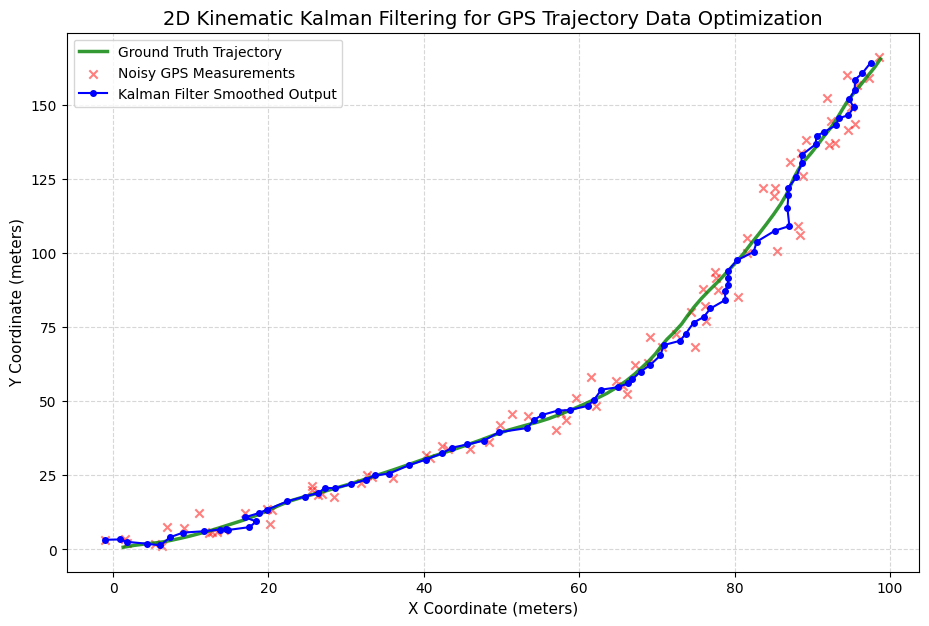

In [4]:
import numpy as np
import matplotlib.pyplot as plt

class GPSKalmanFilter2D:
    def __init__(self, dt, sigma_a, sigma_m, initial_pos=(0.0, 0.0)):
        """
        dt: Time step interval
        sigma_a: Acceleration process noise standard deviation
        sigma_m: GPS measurement noise standard deviation
        """
        self.dt = dt

        # State Vector initialization: [px, py, vx, vy]^T
        self.x = np.array([[initial_pos[0]],
                           [initial_pos[1]],
                           [0.0],
                           [0.0]])

        # State Covariance matrix initialization (high initial uncertainty)
        self.P = np.eye(4) * 10.0

        # Transition Matrix (A)
        self.A = np.array([[1.0, 0.0, dt,  0.0],
                           [0.0, 1.0, 0.0, dt ],
                           [0.0, 0.0, 1.0, 0.0],
                           [0.0, 0.0, 0.0, 1.0]])

        # Noise Input Matrix (G)
        self.G = np.array([[0.5 * (dt**2), 0.0],
                           [0.0, 0.5 * (dt**2)],
                           [dt,  0.0],
                           [0.0, dt]])

        # Process Noise Covariance (Q = G * Sigma_p * G^T)
        Sigma_p = np.eye(2) * (sigma_a**2)
        self.Q = self.G @ Sigma_p @ self.G.T

        # Measurement Matrix (H)
        self.H = np.array([[1.0, 0.0, 0.0, 0.0],
                           [0.0, 1.0, 0.0, 0.0]])

        # Measurement Noise Covariance (R)
        self.R = np.eye(2) * (sigma_m**2)

    def predict(self):
        """Predicts the state and state covariance forward in time."""
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.Q
        return self.x

    def update(self, z_meas):
        """Updates the state estimate using a new noisy GPS measurement vector."""
        # Innovation vector (v)
        v = z_meas - (self.H @ self.x)

        # Innovation Covariance (S)
        S = self.H @ self.P @ self.H.T + self.R

        # Kalman Gain (K)
        K = self.P @ self.H.T @ np.linalg.inv(S)

        # Posterior state and covariance estimation
        self.x = self.x + K @ v
        self.P = (np.eye(4) - K @ self.H) @ self.P
        return self.x

# --- Simulation and Execution Script ---
if __name__ == "__main__":
    np.random.seed(24)
    num_steps = 80
    dt = 1.0

    # Noise tuning parameters
    true_acceleration_noise = 0.15
    gps_measurement_noise = 2.5

    # 1. Generate Synthetic True Trajectory (Constant Velocity + Random acceleration)
    true_positions = []
    curr_x = np.array([[0.0], [0.0], [1.2], [0.8]]) # x0, y0, vx0, vy0
    A_gen = np.array([[1, 0, dt, 0], [0, 1, 0, dt], [0, 0, 1, 0], [0, 0, 0, 1]])
    G_gen = np.array([[0.5*(dt**2), 0], [0, 0.5*(dt**2)], [dt, 0], [0, dt]])

    for _ in range(num_steps):
        w = np.random.normal(0, true_acceleration_noise, (2, 1))
        curr_x = A_gen @ curr_x + G_gen @ w
        true_positions.append((curr_x[0, 0], curr_x[1, 0]))

    true_positions = np.array(true_positions)

    # 2. Generate Corrupted Noisy GPS Measurements
    noise = np.random.normal(0, gps_measurement_noise, (num_steps, 2))
    measured_positions = true_positions + noise

    # 3. Filter the measurements using our Kalman Filter instance
    kf = GPSKalmanFilter2D(dt=dt, sigma_a=0.2, sigma_m=gps_measurement_noise, initial_pos=measured_positions[0])
    filtered_positions = []

    for k in range(num_steps):
        kf.predict()
        z = measured_positions[k].reshape(2, 1)
        x_post = kf.update(z)
        filtered_positions.append((x_post[0, 0], x_post[1, 0]))

    filtered_positions = np.array(filtered_positions)

    # 4. Generate Performance Comparison Visualization Plot
    plt.figure(figsize=(11, 7))
    plt.plot(true_positions[:, 0], true_positions[:, 1], 'g-', label='Ground Truth Trajectory', alpha=0.8, lw=2.5)
    plt.scatter(measured_positions[:, 0], measured_positions[:, 1], color='red', marker='x', alpha=0.5, label='Noisy GPS Measurements')
    plt.plot(filtered_positions[:, 0], filtered_positions[:, 1], 'b-o', label='Kalman Filter Smoothed Output', markersize=4)

    plt.title('2D Kinematic Kalman Filtering for GPS Trajectory Data Optimization', fontsize=14)
    plt.xlabel('X Coordinate (meters)', fontsize=11)
    plt.ylabel('Y Coordinate (meters)', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='best')
    plt.show()